In [1]:
# import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

### Load Data

In [2]:
# load data
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

In [3]:
train.shape

(1460, 81)

### Data Preprocessing

In [4]:
train.isna().sum()

Id                  0
MSSubClass          0
MSZoning            0
LotFrontage       259
LotArea             0
Street              0
Alley            1369
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType        872
MasVnrArea          8
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           37
BsmtCond           37
BsmtExposure       38
BsmtFinType1       37
BsmtFinSF1          0
BsmtFinType2       38
BsmtFinSF2          0
BsmtUnfSF           0
TotalBsmtSF         0
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
1stFlrSF            0
2ndFlrSF            0
LowQualFin

In [5]:
# cat column
cat_col = train.select_dtypes(include=['object']).columns

# NA column
na_col = train.columns[train.isna().sum() > 0]

# NA column with meaning (from the description)
na_col_meaning = ["Alley", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2", "FireplaceQu", "GarageType", "GarageFinish", "GarageQual", "GarageCond", "PoolQC", "Fence", "MiscFeature"]

# NA column meaning - all NA col
na_col_no_meaning = [col for col in na_col if col not in na_col_meaning]

In [6]:
na_col_no_meaning

['LotFrontage', 'MasVnrType', 'MasVnrArea', 'Electrical', 'GarageYrBlt']

In [7]:
# drop Utilities column (only 1 value)
train.drop(columns=["Utilities"], inplace=True)
test.drop(columns=["Utilities"], inplace=True)

In [8]:
# by hand split categorical columns into 3 types
ordinal_cols = ["LotShape","LandContour","LandSlope","HouseStyle","ExterQual","ExterCond","BsmtQual","BsmtCond","BsmtExposure","BsmtFinType1","BsmtFinType2","HeatingQC","KitchenQual","Functional","FireplaceQu","GarageFinish","GarageQual","GarageCond","PavedDrive","PoolQC","Fence"]
cat_cols = ["Street","Alley","CentralAir","BldgType","SaleType","SaleCondition","MSSubClass","MSZoning","Neighborhood","Condition1","Condition2","LotConfig","RoofStyle","RoofMatl","Exterior1st","Exterior2nd","MasVnrType","Foundation","Heating","Electrical","GarageType","MiscFeature"]

threshold = 4 
one_hot_cols = []
freq_cols = []
for col in cat_cols:
    if col in train.columns and train[col].nunique() <= threshold:
        one_hot_cols.append(col)
    else:
        freq_cols.append(col)

In [9]:
# ! this is removed because it changed to use the KNN at the end
# from sklearn.impute import SimpleImputer
# categorical_na = ['MasVnrType', 'Electrical']
# if categorical_na:
#     cat_imputer = SimpleImputer(strategy='most_frequent')
#     train[categorical_na] = cat_imputer.fit_transform(train[categorical_na])
#     test[categorical_na] = cat_imputer.transform(test[categorical_na])

In [10]:
from sklearn.preprocessing import OrdinalEncoder

# define categories in order (this is hard code, using the data_description.tx)
ordinal_categories = [
    ['Reg', 'IR1', 'IR2', 'IR3'],  # LotShape
    ['Lvl', 'Bnk', 'HLS', 'Low'],  # LandContour
    # ['AllPub', 'NoSewr', 'NoSeWa', 'ELO'],  # Utilities
    ['Gtl', 'Mod', 'Sev'],  # LandSlope
    ['1Story', '1.5Fin', '1.5Unf', '2Story', '2.5Fin', '2.5Unf', 'SFoyer', 'SLvl'],  # HouseStyle
    ['Ex', 'Gd', 'TA', 'Fa', 'Po'],  # ExterQual
    ['Ex', 'Gd', 'TA', 'Fa', 'Po'],  # ExterCond
    ['Ex', 'Gd', 'TA', 'Fa', 'Po', 'NA'],  # BsmtQual
    ['Ex', 'Gd', 'TA', 'Fa', 'Po', 'NA'],  # BsmtCond
    ['Gd', 'Av', 'Mn', 'No', 'NA'],  # BsmtExposure
    ['GLQ', 'ALQ', 'BLQ', 'Rec', 'LwQ', 'Unf', 'NA'],  # BsmtFinType1
    ['GLQ', 'ALQ', 'BLQ', 'Rec', 'LwQ', 'Unf', 'NA'],  # BsmtFinType2
    ['Ex', 'Gd', 'TA', 'Fa', 'Po'],  # HeatingQC
    ['Ex', 'Gd', 'TA', 'Fa', 'Po'],  # KitchenQual
    ['Typ', 'Min1', 'Min2', 'Mod', 'Maj1', 'Maj2', 'Sev', 'Sal'],  # Functional
    ['Ex', 'Gd', 'TA', 'Fa', 'Po', 'NA'],  # FireplaceQu
    ['Fin', 'RFn', 'Unf', 'NA'],  # GarageFinish
    ['Ex', 'Gd', 'TA', 'Fa', 'Po', 'NA'],  # GarageQual
    ['Ex', 'Gd', 'TA', 'Fa', 'Po', 'NA'],  # GarageCond
    ['Y', 'P', 'N'],  # PavedDrive
    ['Ex', 'Gd', 'TA', 'Fa', 'NA'],  # PoolQC
    ['GdPrv', 'MnPrv', 'GdWo', 'MnWw', 'NA']  # Fence
]

# fit encoder on train (handle NA by filling with 'NA' first)
for col in ordinal_cols:
    if col in train.columns:
        cat_list = ordinal_categories[ordinal_cols.index(col)]
        if 'NA' in cat_list:
            train[col] = train[col].fillna('NA')
            test[col] = test[col].fillna('NA')
        else:
            mode = train[col].mode()[0]
            train[col] = train[col].fillna(mode)
            test[col] = test[col].fillna(mode)

encoder = OrdinalEncoder(categories=ordinal_categories)
train[ordinal_cols] = encoder.fit_transform(train[ordinal_cols])
test[ordinal_cols] = encoder.transform(test[ordinal_cols])

In [11]:
# one hot encoding for column with few category
train = pd.get_dummies(train, columns=one_hot_cols, drop_first=True)
test = pd.get_dummies(test, columns=one_hot_cols, drop_first=True)

missing_cols = set(train.columns) - set(test.columns)
for col in missing_cols:
    test[col] = 0
extra_cols = set(test.columns) - set(train.columns)
test = test.drop(columns=extra_cols)
test = test[train.columns]

missing_cols = set(train.columns) - set(test.columns)
for col in missing_cols:
    test[col] = 0
extra_cols = set(test.columns) - set(train.columns)
test = test.drop(columns=extra_cols)

In [12]:
# frequency encoding for column with many category
for col in freq_cols:
    if col in train.columns:
        freq_map = train[col].value_counts(normalize=True)
        train[col + '_freq'] = train[col].map(freq_map)
        test[col + '_freq'] = test[col].map(freq_map).fillna(0)
        train.drop(columns=[col], inplace=True)
        test.drop(columns=[col], inplace=True)

In [13]:
print("train shape after encoding:", train.shape)
print("test shape after encoding:", test.shape)

train shape after encoding: (1460, 83)
test shape after encoding: (1459, 83)


In [14]:
# combine bathroom columns (reduce dimensionality)
train['No. of bathrooms']=train['BsmtFullBath']+0.5*train['BsmtHalfBath']+train['FullBath']+0.5*train['HalfBath']
test['No. of bathrooms']=test['BsmtFullBath']+0.5*test['BsmtHalfBath']+test['FullBath']+0.5*test['HalfBath']
train.drop(columns=['BsmtFullBath','BsmtHalfBath','FullBath','HalfBath'],inplace=True)
test.drop(columns=['BsmtFullBath','BsmtHalfBath','FullBath','HalfBath'],inplace=True)

In [15]:
# filling missing value using KNN method
from sklearn.impute import KNNImputer
knn_imputer = KNNImputer(n_neighbors=5)  # adjust k as needed
train = pd.DataFrame(knn_imputer.fit_transform(train), columns=train.columns)
test = pd.DataFrame(knn_imputer.transform(test), columns=test.columns)

In [16]:
# reorder
order = ['Id', 'LotFrontage', 'LotArea', 'LotShape', 'LandContour', 'LandSlope', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'HeatingQC', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'No. of bathrooms', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC', 'Fence', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice', 'Street_Pave', 'Alley_Pave', 'CentralAir_Y', 'MasVnrType_BrkFace', 'MasVnrType_Stone', 'MiscFeature_Othr', 'MiscFeature_Shed', 'MiscFeature_TenC', 'BldgType_freq', 'SaleType_freq', 'SaleCondition_freq', 'MSSubClass_freq', 'MSZoning_freq', 'Neighborhood_freq', 'Condition1_freq', 'Condition2_freq', 'LotConfig_freq', 'RoofStyle_freq', 'RoofMatl_freq', 'Exterior1st_freq', 'Exterior2nd_freq', 'Foundation_freq', 'Heating_freq', 'Electrical_freq', 'GarageType_freq']
train = train.loc[:,order]
test = test.loc[:,order]
train['Id'] = train['Id'].round().astype(int)
test['Id'] = test['Id'].round().astype(int)

In [17]:
# train.to_csv('data/train_cleaned.csv', index=False)
# test.to_csv('data/test_cleaned.csv', index=False)

### Load Data

In [18]:
# load cleaned dataset
# train = pd.read_csv('data/train_cleaned.csv')
# test = pd.read_csv('data/test_cleaned.csv')
y = train[["SalePrice"]]
test_ids = test['Id'] # for submit to kaggle

train.drop(columns=["Id","SalePrice"],inplace=True)
test.drop(columns=["Id"],inplace=True)

# train test split
X = train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

### Feature Selection

In [19]:
# stepwise AIC feature selection (compare to BIC, it can allow more features)
def stepwise_aic(X, y, initial_features=None):
    included = list(initial_features) if initial_features else []

    def aic_of(features):
        if not features:
            return np.inf
        return sm.OLS(y, sm.add_constant(X[features])).fit().aic

    current_aic = aic_of(included)

    while True:
        changed = False

        # forward
        excluded = list(set(X.columns) - set(included))
        add_candidates = {col: aic_of(included + [col]) for col in excluded}
        if add_candidates:
            best_add_feature = min(add_candidates, key=add_candidates.get)
            best_add_aic = add_candidates[best_add_feature]
        else:
            best_add_feature, best_add_aic = None, np.inf

        # backward
        remove_candidates = {col: aic_of([c for c in included if c != col]) for col in included}
        if remove_candidates:
            best_remove_feature = min(remove_candidates, key=remove_candidates.get)
            best_remove_aic = remove_candidates[best_remove_feature]
        else:
            best_remove_feature, best_remove_aic = None, np.inf

        # print best move
        best_move_aic = min(best_add_aic, best_remove_aic, current_aic)

        if best_move_aic < current_aic:
            if best_add_aic < best_remove_aic:
                included.append(best_add_feature)
                current_aic = best_add_aic
                changed = True
                print(f"Add    {best_add_feature:>20}, AIC = {best_add_aic:.2f}")
            else:
                included.remove(best_remove_feature)
                current_aic = best_remove_aic
                changed = True
                print(f"Remove {best_remove_feature:>20}, AIC = {best_remove_aic:.2f}")

        if not changed:
            print("AIC Done! #feature = ", len(included))
            break

    return included

In [20]:
included = stepwise_aic(X_train,y_train)

Add             OverallQual, AIC = 28488.02
Add               GrLivArea, AIC = 28192.60
Add              BsmtFinSF1, AIC = 28069.49
Add              GarageCars, AIC = 27960.48
Add               ExterQual, AIC = 27885.89
Add         MSSubClass_freq, AIC = 27826.35
Add            BsmtExposure, AIC = 27765.73
Add             KitchenQual, AIC = 27741.25
Add       Neighborhood_freq, AIC = 27714.19
Add             FireplaceQu, AIC = 27698.95
Add         Condition1_freq, AIC = 27683.66
Add              Functional, AIC = 27672.97
Add                 LotArea, AIC = 27663.90
Add              GarageCond, AIC = 27655.59
Add             OverallCond, AIC = 27646.99
Add        No. of bathrooms, AIC = 27637.58
Add          RoofStyle_freq, AIC = 27630.21
Add           BldgType_freq, AIC = 27622.58
Add                BsmtQual, AIC = 27616.52
Add                BsmtCond, AIC = 27606.83
Add              HouseStyle, AIC = 27600.09
Add              MasVnrArea, AIC = 27592.66
Add      MasVnrType_BrkFace, AIC

In [21]:
# using selected features
X_train_aic = X_train[included]
X_test_aic = X_test[included]
test_aic = test[included]

<Axes: >

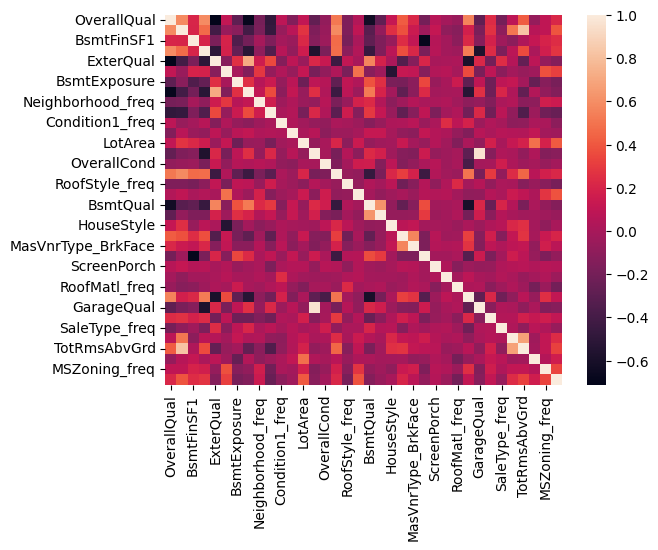

In [22]:
# this is for further removing the feature by correlation
corr = X_train_aic.corr()
sns.heatmap(corr)

In [23]:
# # triangle matrix for delete
# corr = X_train.corr().abs()
# upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# # columns to drop
# to_drop = [column for column in upper.columns if any(upper[column] > 0.75)]
# print(to_drop)
# X_train_corr = X_train.drop(columns=to_drop)
# X_test_corr = X_test.drop(columns=to_drop)
# test_corr = test.drop(columns=to_drop)

In [24]:
# # corr after
# corr = X_train_corr.corr()
# sns.heatmap(corr)

### Train Model

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

In [26]:
# Linear Regression
model = LinearRegression()

# No log transformation in training
reg = model.fit(X_train_aic,y_train)
y_pred = reg.predict(X_test_aic)
print("No log transformation")
print(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))
print('R^2: ',reg.score(X_test_aic,y_test))

# With log transformation in training
reg = model.fit(X_train_aic,np.log(y_train+1))
y_pred = reg.predict(X_test_aic)
y_pred = np.exp(y_pred)-1
print("\nWith log transformation")
print(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))
print('R^2: ',reg.score(X_test_aic,np.log(y_test+1)))

No log transformation
0.25584082730485325
R^2:  0.8463087351750634

With log transformation
0.14941624977821527
R^2:  0.8803672373540972


In [27]:
# Decision Tree
model = DecisionTreeRegressor(random_state=42)

# No log transformation in training
reg = model.fit(X_train_aic,y_train)
y_pred = reg.predict(X_test_aic)
print("No log transformation")
print(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))
print('R^2: ',reg.score(X_test_aic,y_test))

# With log transformation in training
reg = model.fit(X_train_aic,np.log(y_train+1))
y_pred = reg.predict(X_test_aic)
y_pred = np.exp(y_pred)-1
print("\nWith log transformation")
print(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))
print('R^2: ',reg.score(X_test_aic,np.log(y_test+1)))

No log transformation
0.20962947646760036
R^2:  0.7343809729300311

With log transformation
0.2039263381024547
R^2:  0.7771554062605186


In [28]:
# Random Forest
model = RandomForestRegressor(random_state=42)

# No log transformation in training
reg = model.fit(X_train_aic,y_train)
y_pred = reg.predict(X_test_aic)
print("No log transformation")
print(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))
print('R^2: ',reg.score(X_test_aic,y_test))

# With log transformation in training
reg = model.fit(X_train_aic,np.log(y_train+1))
y_pred = reg.predict(X_test_aic)
y_pred = np.exp(y_pred)-1
print("\nWith log transformation")
print(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))
print('R^2: ',reg.score(X_test_aic,np.log(y_test+1)))

No log transformation
0.15037906023853911
R^2:  0.8872672638720708

With log transformation
0.14918367969729543
R^2:  0.880739304963448


In [29]:
# XGBoost without hyperparameter tuning
model = xgb.XGBRegressor(objective='reg:squarederror',
                         n_estimators=100, random_state=42)

# No log transformation in training
reg = model.fit(X_train_aic,y_train)
y_pred = reg.predict(X_test_aic)
print("No log transformation")
print(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))
print('R^2: ',reg.score(X_test_aic,y_test))

# With log transformation in training
reg = model.fit(X_train_aic,np.log(y_train+1))
y_pred = reg.predict(X_test_aic)
y_pred = np.exp(y_pred)-1
print("\nWith log transformation")
print(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))
print('R^2: ',reg.score(X_test_aic,np.log(y_test+1)))

No log transformation
0.1493038319394576
R^2:  0.8931635618209839

With log transformation
0.1486324736382009
R^2:  0.8816190361976624


In [39]:
import optuna


def objective(trial):
    params = {
        'objective': 'reg:squarederror',
        'max_depth': trial.suggest_int('max_depth', 4, 8),
        'subsample': trial.suggest_float('subsample', 0.8, 1.0, step=0.05),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.8, 1.0, step=0.05),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.8, 1.2, step=0.05),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 0.5, step=0.05),
        'gamma': trial.suggest_float('gamma', 0.0, 0.2, step=0.05),
        'learning_rate': 0.1,
        'n_estimators': 300,
        'random_state': 42,
    }

    model = xgb.XGBRegressor(**params)
    model.fit(X_train_aic, y_train)
    y_pred = model.predict(X_test_aic)
    rmse_log = np.sqrt(mean_squared_error(np.log(y_test), np.log(y_pred)))
    return rmse_log


study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=500, n_jobs=-1)

best_params = study.best_trial.params
print("Best RMSE(log):", study.best_value)
print("Best hyperparameters:", best_params)

[I 2025-11-14 17:03:21,652] A new study created in memory with name: no-name-9d043798-9bf6-47c4-80fe-70ff579a2c2e


[I 2025-11-14 17:03:23,131] Trial 4 finished with value: 0.13756689888005655 and parameters: {'max_depth': 4, 'subsample': 1.0, 'colsample_bytree': 0.8500000000000001, 'reg_lambda': 0.8500000000000001, 'reg_alpha': 0.25, 'gamma': 0.15000000000000002}. Best is trial 4 with value: 0.13756689888005655.
[I 2025-11-14 17:03:23,439] Trial 7 finished with value: 0.13660106362133653 and parameters: {'max_depth': 5, 'subsample': 1.0, 'colsample_bytree': 1.0, 'reg_lambda': 0.8500000000000001, 'reg_alpha': 0.25, 'gamma': 0.2}. Best is trial 7 with value: 0.13660106362133653.
[I 2025-11-14 17:03:23,448] Trial 2 finished with value: 0.1363992909713325 and parameters: {'max_depth': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 1.2, 'reg_alpha': 0.4, 'gamma': 0.05}. Best is trial 2 with value: 0.1363992909713325.
[I 2025-11-14 17:03:23,464] Trial 1 finished with value: 0.14090336296328626 and parameters: {'max_depth': 5, 'subsample': 1.0, 'colsample_bytree': 1.0, 'reg_lambda': 1.05, 're

Best RMSE(log): 0.12840642260727617
Best hyperparameters: {'max_depth': 4, 'subsample': 0.8, 'colsample_bytree': 0.9, 'reg_lambda': 1.1, 'reg_alpha': 0.1, 'gamma': 0.0}


In [40]:
# XGBoost with hyperparameter tuning
model = xgb.XGBRegressor(**best_params, objective='reg:squarederror', learning_rate=0.1, n_estimators=1000, random_state=42)

reg = model.fit(X_train_aic, y_train, eval_set=[(X_train_aic, y_train),(X_test_aic, y_test)], verbose=False)
y_pred = reg.predict(X_test_aic)
print(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))
print('R^2: ',reg.score(X_test_aic,y_test))

0.1315294588736954
R^2:  0.9145510792732239


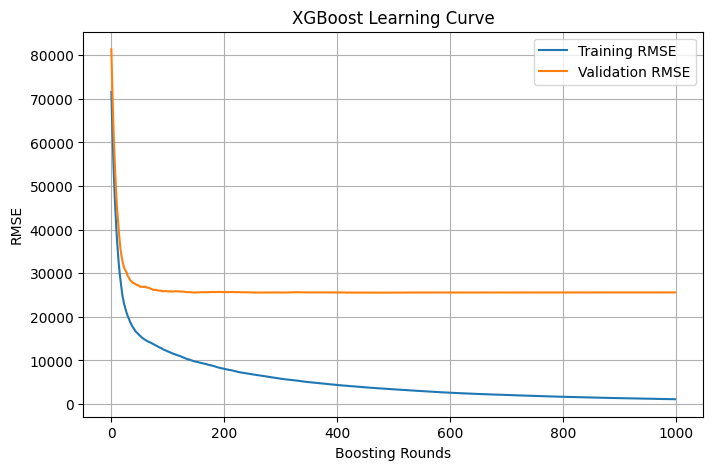

In [41]:
# XGBoost with hyperparameter tuning
results = reg.evals_result()

# Simple learning curve plot (validation RMSE over boosting rounds)
plt.figure(figsize=(8, 5))
plt.plot(results['validation_0']['rmse'], label='Training RMSE')
plt.plot(results['validation_1']['rmse'], label='Validation RMSE')
plt.xlabel('Boosting Rounds')
plt.ylabel('RMSE')
plt.title('XGBoost Learning Curve')
plt.legend()
plt.grid(True)
plt.show()

In [42]:
# XGBoost with hyperparameter tuning
model = xgb.XGBRegressor(**best_params, objective='reg:squarederror', learning_rate=0.1, n_estimators=300, random_state=42)

reg = model.fit(X_train_aic, y_train, eval_set=[(X_train_aic, y_train),(X_test_aic, y_test)], verbose=False)
y_pred = reg.predict(X_test_aic)
print(np.sqrt(mean_squared_error(np.log(y_test),np.log(y_pred))))
print('R^2: ',reg.score(X_test_aic,y_test))

0.12840642260727617
R^2:  0.9146921038627625


In [43]:
test_pred = model.predict(test_aic)
submission_df = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": test_pred
})
submission_df.to_csv("data/submission.csv", index=False)